# Overflow Isopycnals

We need to identify the isopycnals that connect the ANtarctic Shelf to the Bottom, to build up a [pretty movie](https://www.youtube.com/watch?v=8VMSF28J9H4) of DSW overflow. Let's check in which isopycnals the overflow occurs, in Ross and Weddell Sea for the creation of those movies with Panan0025

In [1]:
import cosima_cookbook as cc
import matplotlib.pyplot as plt
import netCDF4 as nc
import seaborn as sns
import xarray as xr
import numpy as np
import os
from dask.distributed import Client
# Optional modules
import xgcm
# Ignore warnings
import logging
logging.captureWarnings(True)
logging.getLogger('py.warnings').setLevel(logging.ERROR)

In [2]:
client = Client()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 7
Total threads: 28,Total memory: 251.20 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:45221,Workers: 7
Dashboard: /proxy/8787/status,Total threads: 28
Started: Just now,Total memory: 251.20 GiB
Comm: tcp://127.0.0.1:35839,Total threads: 4
Dashboard: /proxy/41725/status,Memory: 35.89 GiB
Nanny: tcp://127.0.0.1:37471,


In [3]:
import cosima_cookbook as cc
session = cc.database.create_session()
expt = 'panant-0025-zstar-ACCESSyr2'
lat_slice = slice(-80, -57.6)

In [5]:
start_time='2000-01'
end_time='2000-12'

In [78]:
#Importing salinity, temperature and density

so = cc.querying.getvar(expt, 'so', session,\
                            start_time=start_time, end_time=end_time,frequency='1 monthly',\
                           chunks={'xh':'100gb','yh':'100gb'}).sel(yh=lat_slice)

thetao = cc.querying.getvar(expt, 'thetao', session,\
                            start_time=start_time, end_time=end_time,frequency='1 monthly',\
                           chunks={'xh':'100gb','yh':'100gb'}).sel(yh=lat_slice)

tob = cc.querying.getvar(expt, 'tob', session,\
                            start_time=start_time, end_time=end_time,frequency='1 monthly',\
                           chunks={'xh':'100gb','yh':'100gb'}).sel(yh=lat_slice)



rho2 = cc.querying.getvar(expt, 'rhopot2', session,\
                            start_time=start_time, end_time=end_time,frequency='1 monthly',\
                           chunks={'xh':'100gb','yh':'100gb'}).sel(yh=lat_slice)

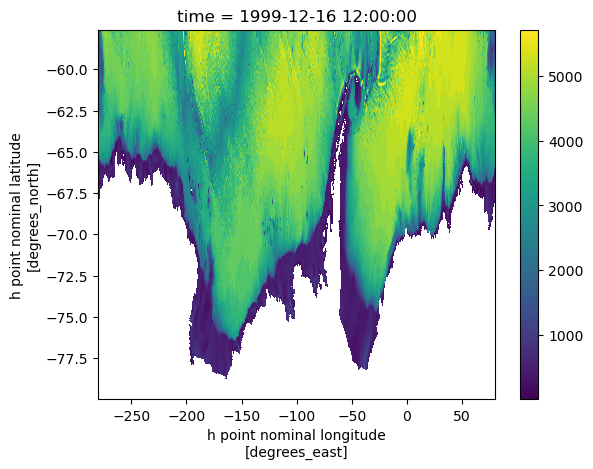

In [21]:
#depth of the bottom will be
HTmax = thetao*0 + thetao.z_l
HTmax =HTmax.isel(time=0).max('z_l')
HTmax.load()
HTmax.plot()

In [86]:
tobmean=tob.mean('time').load()

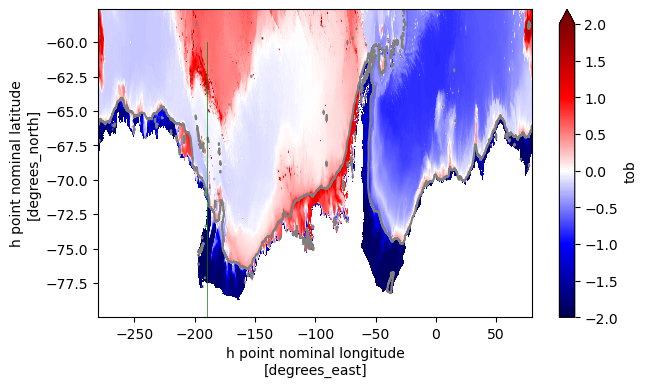

In [90]:
#LEts make a simple Tob plot to see when we likely see AABW 
plt.figure(figsize=(7,4))
tobmean.plot(vmin=-2,vmax=2,cmap='seismic')
plt.contour(HTmax.xh,HTmax.yh,HTmax,[1000],colors='gray',linewidth=0.2)
plt.plot([-190,-190],[-80,-60],color='green',lw=0.5)


## Ross Sea

Will be roughly between -220 and -150

In [24]:
Ross_lon=slice(-220,-140)
HTmax=HTmax.fillna(0)

In [26]:
from mpl_toolkits import mplot3d 

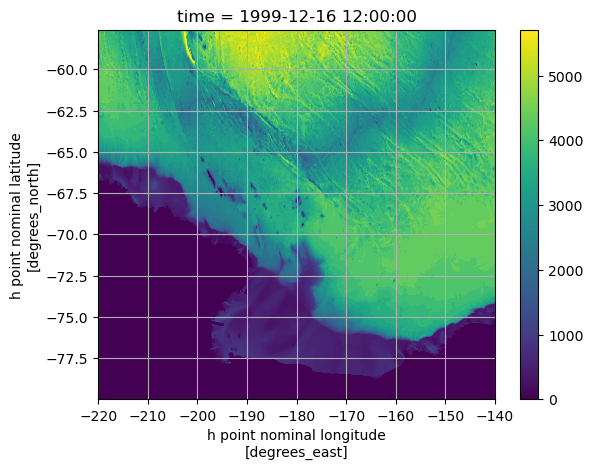

In [34]:
HTmax.sel(xh=Ross_lon).plot()
plt.grid()

Lets first see a section around -188.5

In [121]:
lon0=-189.9
rho2_190 = rho2.sel(xh=lon0,method='nearest')-1000
theta_190 = thetao.sel(xh=lon0,method='nearest')
S_190 = so.sel(xh=lon0,method='nearest')

In [403]:

figdir='/home/156/wf4500/v45_wf4500/Project_panan/GH/Panan_HT_ASC/figs/'

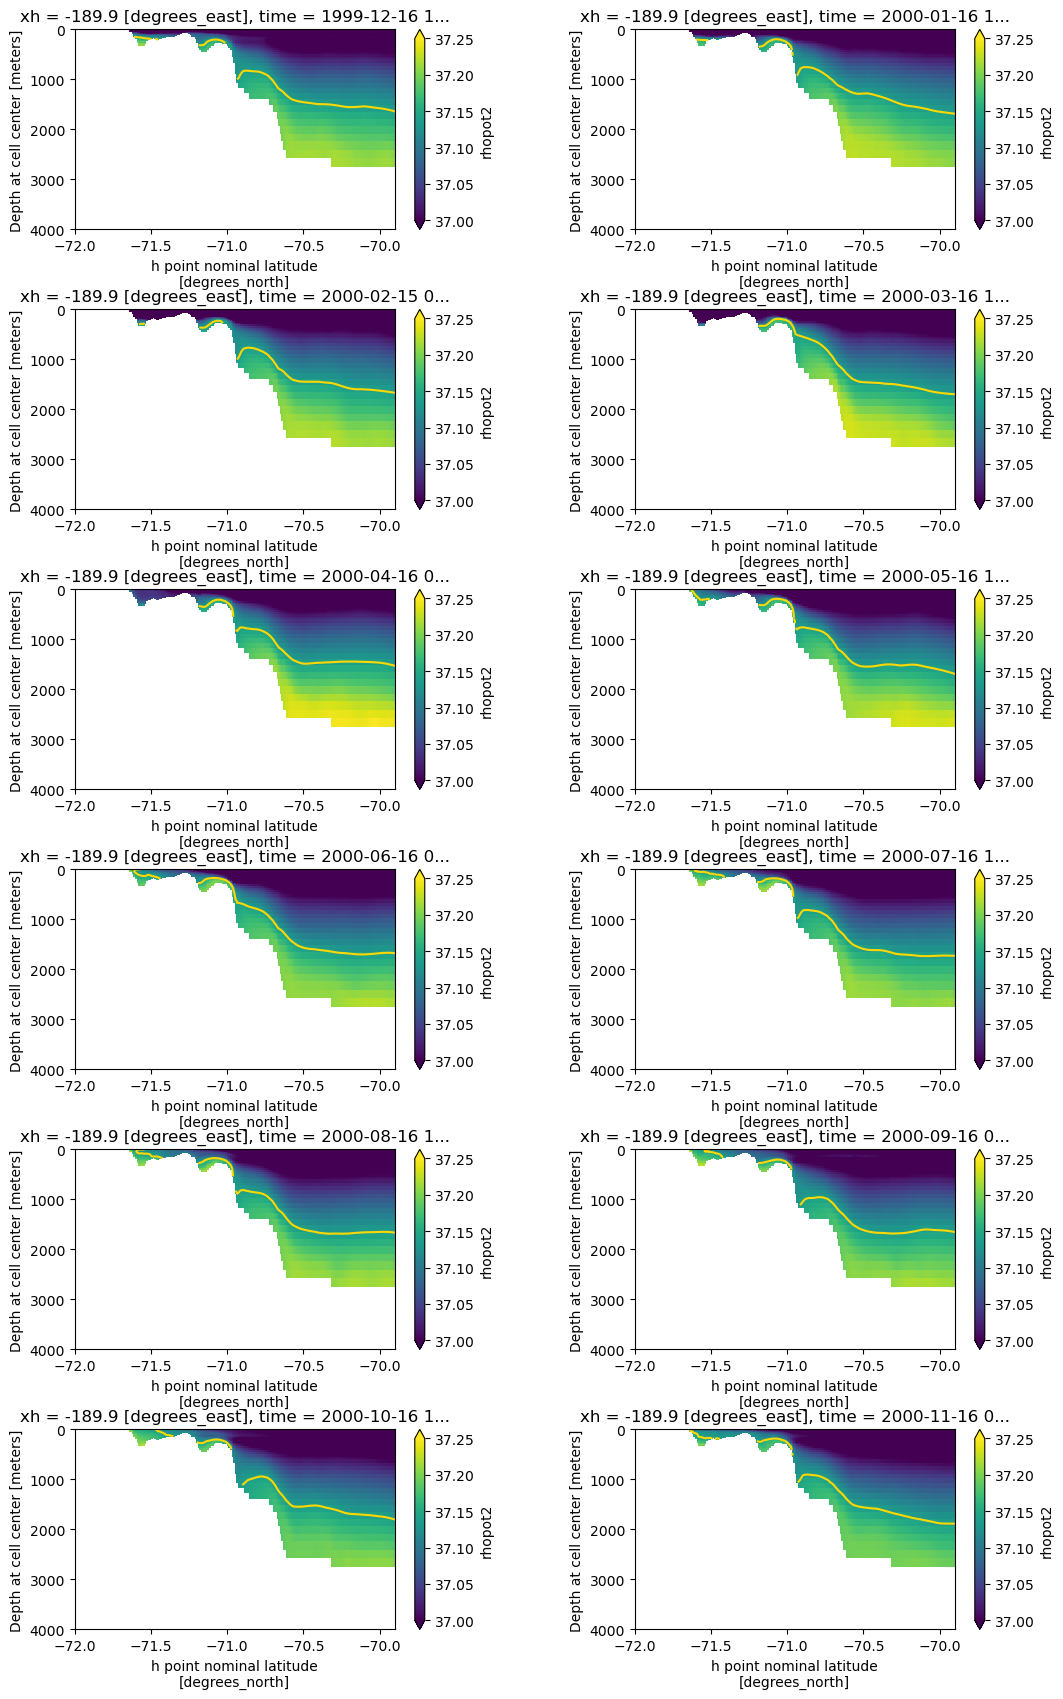

In [495]:
plt.figure(figsize=(12,20))
plt.subplots_adjust(left=0.1,
                    bottom=0.1,
                    right=0.9,
                    top=0.9,
                    wspace=0.4,
                    hspace=0.4)

for n in range(0,12):
    plt.subplot(6,2,n+1)
    rho2_190.isel(time=n).plot(vmin=37.0,vmax=37.25)
    plt.contour(rho2_190.yh,rho2_190.z_l,rho2_190.isel(time=n),[37.14021775451],colors='gold',lw=0.5)
    plt.ylim(4000,0); plt.xlim(-72,-69.9)

plt.savefig(figdir+'SLice_190_ROss_Sea_Density.png',dpi=300,bbox_inches='tight')

In [267]:
#test 3d plot
from mpl_toolkits.mplot3d import Axes3D
from sys import argv
from matplotlib import cbook, cm
from matplotlib.colors import LightSource
lat_slice2=slice(-80,-62)
ROSS_HTmax = HTmax.sel(xh=Ross_lon).sel(yh=lat_slice2).drop('time')
x=np.tile(np.array(ROSS_HTmax.xh),[1690,1])
y=np.tile(np.array(ROSS_HTmax.yh.sel(yh=lat_slice2)),[3200,1]).T
z_l=rho2.z_l

In [282]:
#rho2_june is the depth closest to thne
rho2_june = rho2.isel(time=6).sel(xh=Ross_lon).sel(yh=lat_slice2).drop('time') -1000 #june
rho2_june = np.abs(rho2_june.fillna(0) - 37.14021775451).argmin('z_l',skipna='True').compute()
rho2_june = z_l.isel(z_l=rho2_june)
rho2_june =rho2_june.where(rho2_june>0.7)

In [310]:
#Importing cell volume of rho , for june, for rho2_l closest to 37.14021775451
ROSS_volrho = cc.querying.getvar(expt, 'volcello', session,ncfile='%month_rho2%',\
                            start_time=start_time, end_time=end_time,frequency='1 monthly',\
                           chunks={'xh':'100gb','yh':'100gb'}).sel(yh=lat_slice)\
.isel(time=6).drop('time').isel(rho2_l=76).drop('rho2_l').sel(xh=Ross_lon).sel(yh=lat_slice2)

ROSS_tarea = cc.querying.getvar(expt, 'areacello', session,n=1,\
                           chunks={'xh':'100gb','yh':'100gb'}).sel(yh=lat_slice)\
.sel(xh=Ross_lon).sel(yh=lat_slice2)

In [318]:
#thickness of the 37.14 layer
ROSS_3714_thickness= (ROSS_volrho /ROSS_tarea)
ROSS_3714_thickness=ROSS_3714_thickness.where(ROSS_3714_thickness>0).compute()

In [467]:
#top of the layer 37.14
ROSS_3714_top = rho2_june - (ROSS_3714_thickness)/2
ROSS_3714_top = ROSS_3714_top.where(ROSS_3714_top>0)
#bottom of the layer 37.14
ROSS_3714_bottom = rho2_june + (ROSS_3714_thickness)/2
ROSS_3714_bottom = ROSS_3714_bottom.where(ROSS_3714_bottom>0)

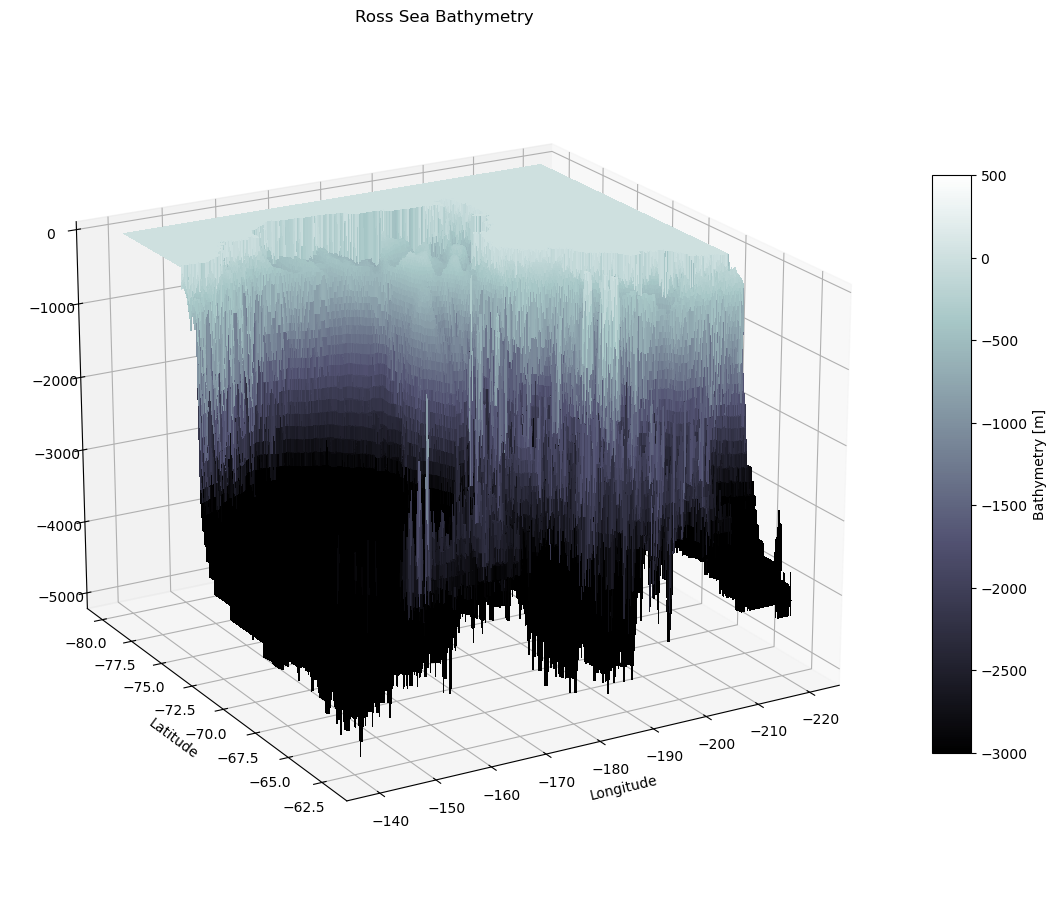

In [492]:
fig = plt.figure(figsize =(14, 15))
ax = plt.axes(projection ='3d')

ls = LightSource(-300, 30)
surf = ax.plot_surface(x, y, -ROSS_HTmax,  cmap='bone',vmin=-3000,vmax=500,\
                        antialiased=False,linewidth=0,rcount=500, ccount=500,\
                      shade='True',lightsource=ls); 
fig.colorbar(surf, shrink=0.5, aspect=15,label='Bathymetry [m]')


plt.title("Ross Sea Bathymetry")
plt.xlabel('Longitude')
plt.ylabel('Latitude')

ax.view_init(-1420, 60)



plt.savefig(figdir+'Ross_Sea_bathymetry.png',dpi=300,bbox_inches='tight')

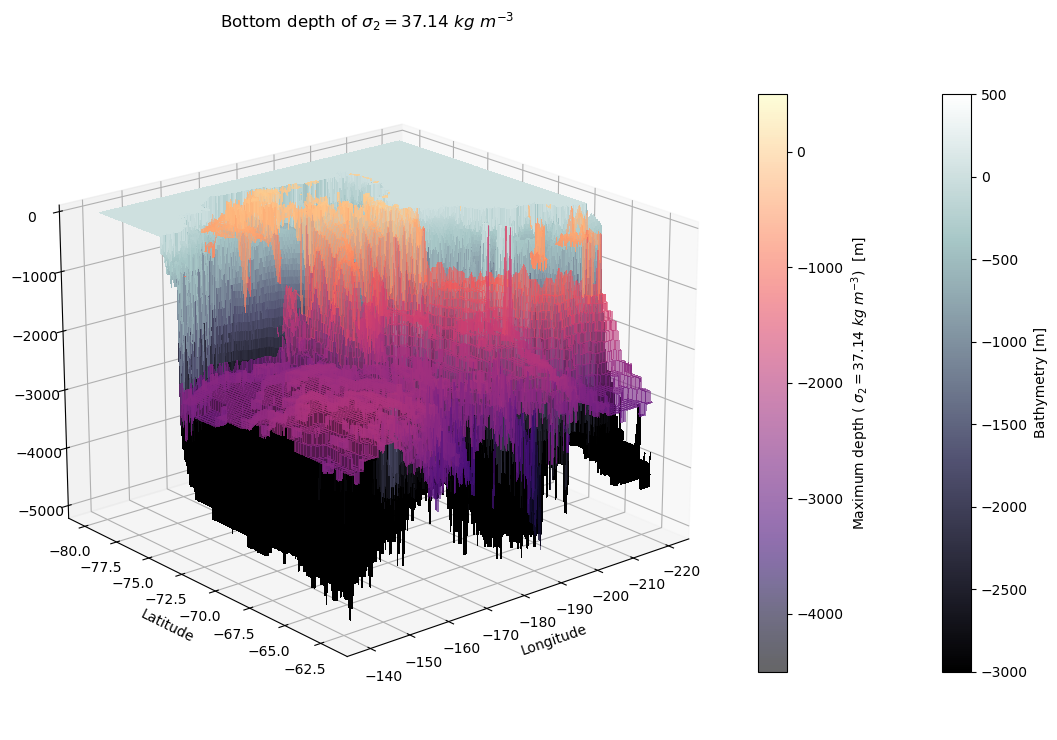

In [493]:
fig = plt.figure(figsize =(14, 15))
ax = plt.axes(projection ='3d')


surf = ax.plot_surface(x, y, -ROSS_HTmax,  cmap='bone',vmin=-3000,vmax=500,\
                        antialiased=False,linewidth=0,rcount=500, ccount=500,\
                      shade='True',lightsource=ls);
fig.colorbar(surf, shrink=0.5, aspect=20,label='Bathymetry [m]')

surf2 = ax.plot_surface(x, y, -ROSS_3714_bottom,  cmap='magma',vmin=-4500,vmax=500,alpha=0.6,\
                       antialiased=False,linewidth=0,rcount=100, ccount=100,\
                      shade='True',lightsource=ls)
fig.colorbar(surf2, shrink=0.5, aspect=20,label=r"Maximum depth ( $\sigma_2=37.14\ kg\ m^{-3})$  [m]")
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title(r"Bottom depth of $\sigma_2=37.14\ kg\ m^{-3}$")

ax.view_init(-1420, 50)


plt.savefig(figdir+'Ross_Sea_3714_surf.png',dpi=300,bbox_inches='tight')

## Weddell Sea

Longitude slice from -60 to -40

In [422]:
Weddell_lon=slice(-63,-40)

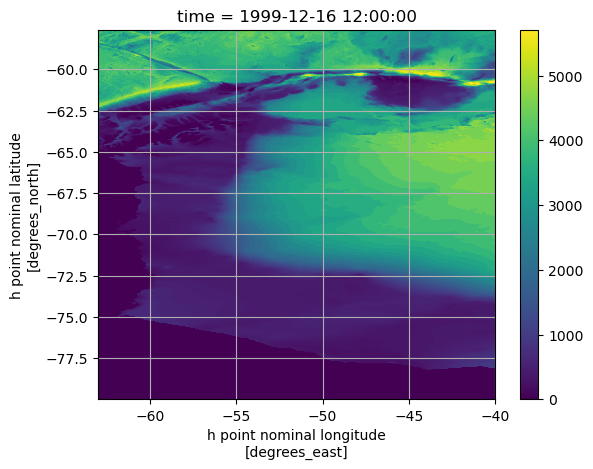

In [423]:
HTmax.sel(xh=Weddell_lon).plot()
plt.grid()

Here we would be mostly interested in a transect along a paralel. Lets try it at -68

In [427]:
lat0=-68
rho2_68 = rho2.sel(yh=lat0,method='nearest').sel(xh=Weddell_lon)-1000
theta_68 = thetao.sel(yh=lat0,method='nearest').sel(xh=Weddell_lon)
S_68 = so.sel(yh=lat0,method='nearest').sel(xh=Weddell_lon)

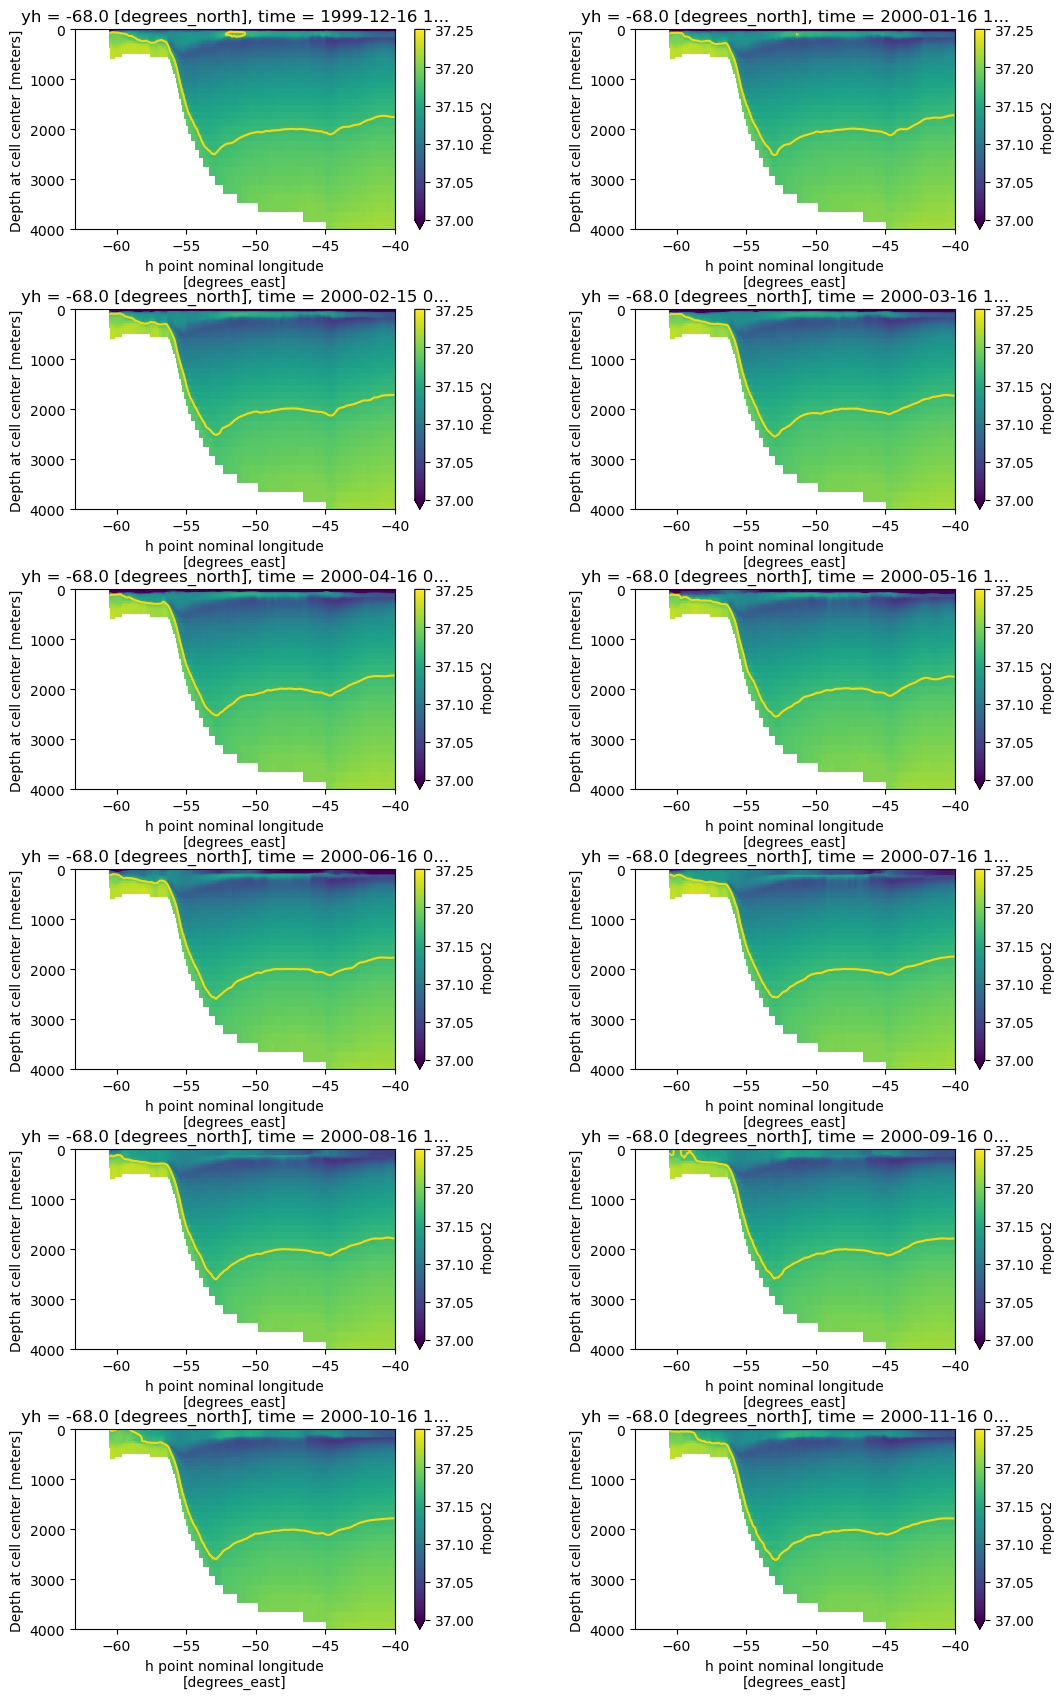

In [494]:
plt.figure(figsize=(12,20))
plt.subplots_adjust(left=0.1,
                    bottom=0.1,
                    right=0.9,
                    top=0.9,
                    wspace=0.4,
                    hspace=0.4)

for n in range(0,12):
    plt.subplot(6,2,n+1)
    rho2_68.isel(time=n).plot(vmin=37.0,vmax=37.25)
    plt.contour(rho2_68.xh,rho2_68.z_l,rho2_68.isel(time=n),[37.17021775],colors='gold',lw=0.5)
    plt.ylim(4000,0); #plt.xlim(-72,-69.9)

plt.savefig(figdir+'Slice_68_Weddell_Sea_Density.png',dpi=300,bbox_inches='tight')

In [458]:
#rho2_june is the depth closest to thne
rho2_wjune = rho2.isel(time=6).sel(xh=Weddell_lon).sel(yh=lat_slice2).drop('time') -1000 #june
rho2_wjune = np.abs(rho2_wjune.fillna(0) - 37.17021775).argmin('z_l',skipna='True').compute()
rho2_wjune = z_l.isel(z_l=rho2_wjune)
rho2_wjune =rho2_wjune.where(rho2_wjune>0.7)

In [443]:
#Importing cell volume of rho , for june, for rho2_l closest to 1037.17021775
WEDDELL_volrho = cc.querying.getvar(expt, 'volcello', session,ncfile='%month_rho2%',\
                            start_time=start_time, end_time=end_time,frequency='1 monthly',\
                           chunks={'xh':'100gb','yh':'100gb'}).sel(yh=lat_slice)\
.isel(time=6).drop('time').isel(rho2_l=79).drop('rho2_l').sel(xh=Weddell_lon).sel(yh=lat_slice2)

WEDDELL_tarea = cc.querying.getvar(expt, 'areacello', session,n=1,\
                           chunks={'xh':'100gb','yh':'100gb'}).sel(yh=lat_slice)\
.sel(xh=Weddell_lon).sel(yh=lat_slice2)

In [463]:
#thickness of the 37.17 layer
WEDDELL_3717_thickness= (WEDDELL_volrho /WEDDELL_tarea)
WEDDELL_3717_thickness=WEDDELL_3717_thickness.where(WEDDELL_3717_thickness>0).compute()

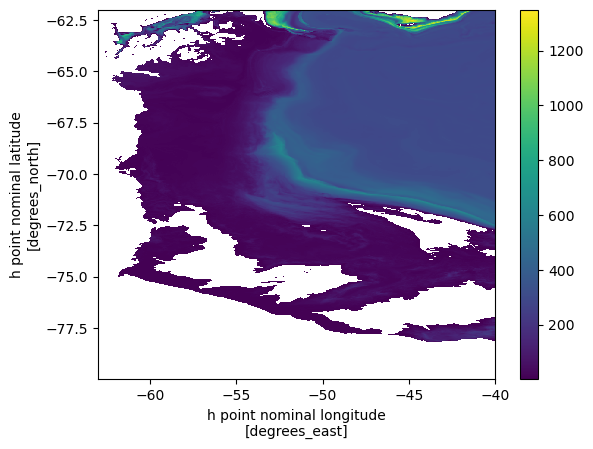

In [465]:
WEDDELL_3717_thickness.plot()

In [468]:
#top of the layer 37.14
WEDDELL_3717_top = rho2_wjune - (WEDDELL_3717_thickness)/2
WEDDELL_3717_top = WEDDELL_3717_top.where(WEDDELL_3717_top>0)
#bottom of the layer 37.14
WEDDELL_3717_bottom = rho2_wjune + (WEDDELL_3717_thickness)/2
WEDDELL_3717_bottom = WEDDELL_3717_bottom.where(WEDDELL_3717_bottom>0)

In [475]:
WEDDELL_HTmax = HTmax.sel(xh=Weddell_lon).sel(yh=lat_slice2).drop('time')
xw=np.tile(np.array(WEDDELL_HTmax.xh),[1690,1])
yw=np.tile(np.array(WEDDELL_HTmax.yh.sel(yh=lat_slice2)),[920,1]).T

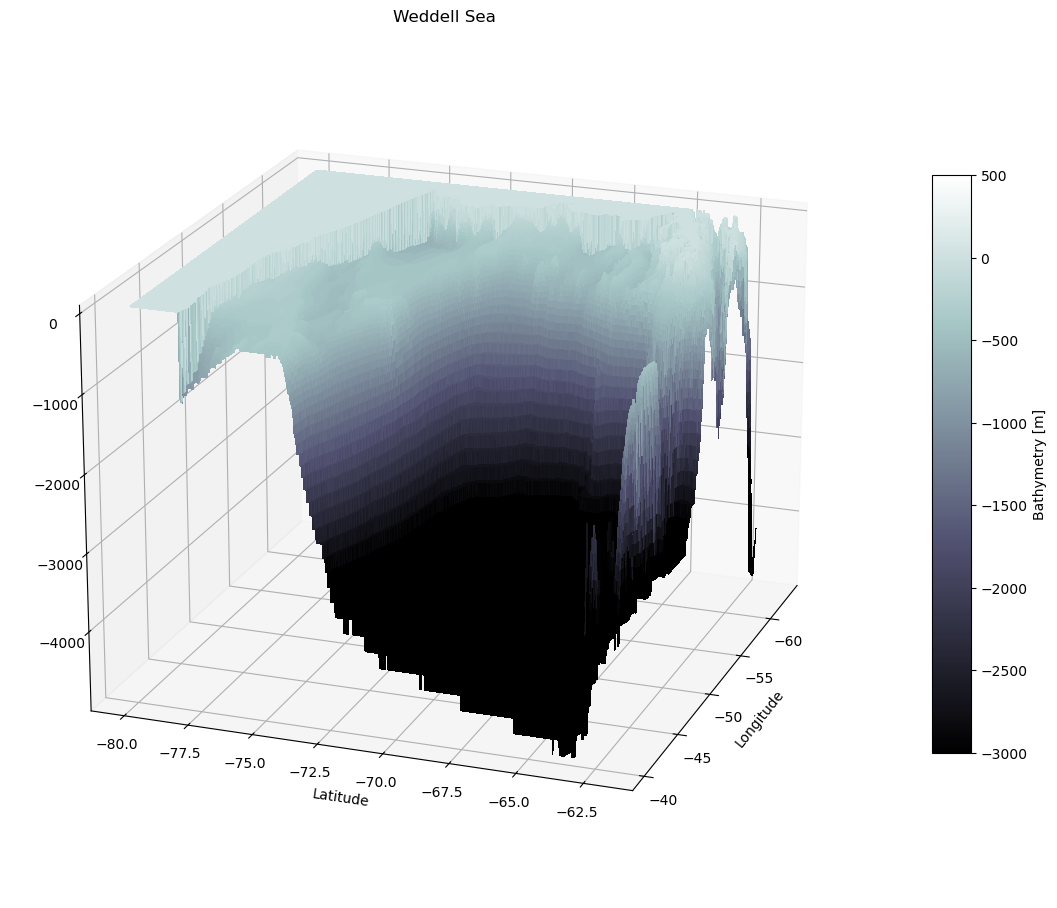

In [496]:
fig = plt.figure(figsize =(14, 15))
ax = plt.axes(projection ='3d')

ls = LightSource(-300, 30)
surf = ax.plot_surface(xw, yw, -WEDDELL_HTmax,  cmap='bone',vmin=-3000,vmax=500,\
                        antialiased=False,linewidth=0,rcount=500, ccount=500,\
                      shade='True',lightsource=ls); 
fig.colorbar(surf, shrink=0.5, aspect=15,label='Bathymetry [m]')


plt.title("Weddell Sea")
plt.xlabel('Longitude')
plt.ylabel('Latitude')

ax.view_init(-1420, 20)



plt.savefig(figdir+'Weddell_Sea_bathymetry.png',dpi=300,bbox_inches='tight')

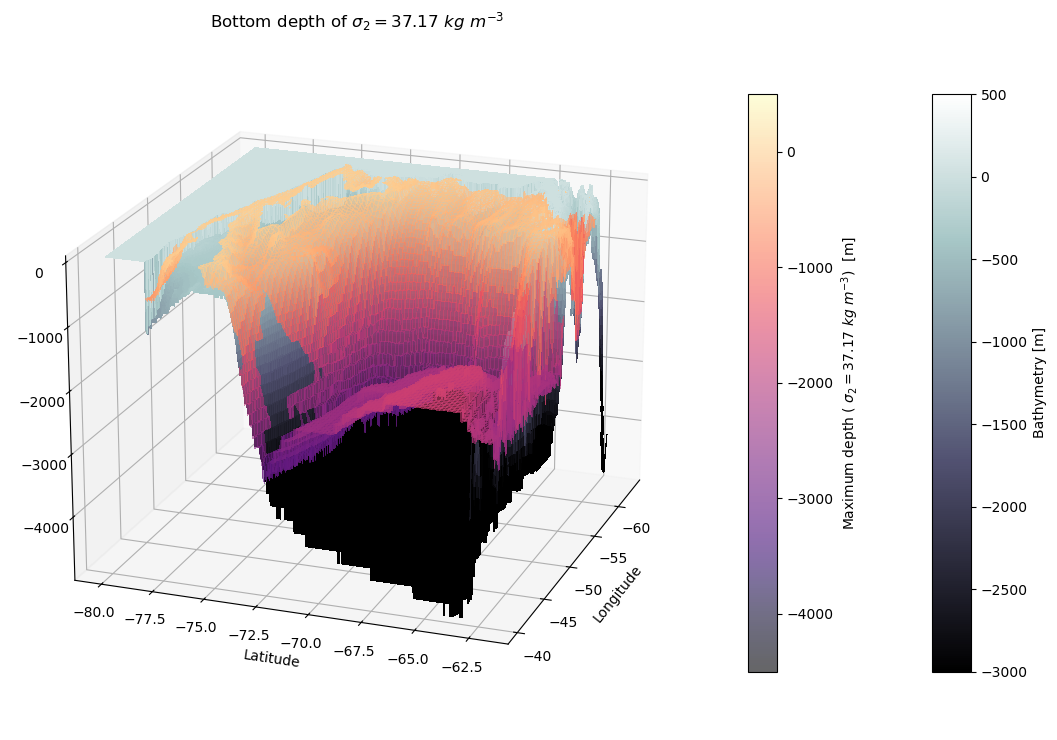

In [497]:
fig = plt.figure(figsize =(14, 15))
ax = plt.axes(projection ='3d')

ls = LightSource(-300, 30)
surf = ax.plot_surface(xw, yw, -WEDDELL_HTmax,  cmap='bone',vmin=-3000,vmax=500,\
                        antialiased=False,linewidth=0,rcount=500, ccount=500,\
                      shade='True',lightsource=ls); 
fig.colorbar(surf, shrink=0.5, aspect=15,label='Bathymetry [m]')


surf2 = ax.plot_surface(xw, yw, -WEDDELL_3717_bottom,  cmap='magma',vmin=-4500,vmax=500,alpha=0.6,\
                       antialiased=False,linewidth=0,rcount=100, ccount=100,\
                      shade='True',lightsource=ls)
fig.colorbar(surf2, shrink=0.5, aspect=20,label=r"Maximum depth ( $\sigma_2=37.17\ kg\ m^{-3})$  [m]")


plt.title(r"Bottom depth of $\sigma_2=37.17\ kg\ m^{-3}$")
plt.xlabel('Longitude')
plt.ylabel('Latitude')

ax.view_init(-1420, 20)



plt.savefig(figdir+'Weddell_Sea_3717_surf.png',dpi=300,bbox_inches='tight')